# Анализ календарных аномалий

Данные загружены в `01_load_data.ipynb`. Здесь: чистка, расчёт
дневных доходностей, проверка различий по дням недели.

In [2]:
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"

In [3]:
prices = pd.read_csv(RAW / "moex_prices.csv", parse_dates=["TRADEDATE"])

print(prices.shape)
prices.head()

(69457, 24)


,BOARDID,TRADEDATE,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
0,TQBR,2014-01-06,Сбербанк,SBER,22830,3.154470e+09,100.20,98.62,100.31,98.63,...,99.54,99.54,3.156739e+09,3.156739e+09,3.156739e+09,NaN,3,SUR,-2.23,NaN
1,TQBR,2014-01-08,Сбербанк,SBER,35633,4.179939e+09,99.10,97.85,99.41,98.20,...,98.65,98.65,4.182984e+09,4.182984e+09,4.182984e+09,NaN,3,SUR,-0.73,NaN
2,TQBR,2014-01-09,Сбербанк,SBER,41567,4.518389e+09,98.44,97.69,98.77,97.97,...,98.25,98.25,4.526414e+09,4.526414e+09,4.526414e+09,NaN,3,SUR,-0.19,NaN
3,TQBR,2014-01-10,Сбербанк,SBER,38198,5.109679e+09,97.87,97.52,99.41,99.41,...,98.45,98.45,5.113831e+09,5.113831e+09,5.113831e+09,NaN,3,SUR,1.22,NaN
4,TQBR,2014-01-13,Сбербанк,SBER,29942,6.191507e+09,99.30,99.04,100.35,100.24,...,99.78,99.78,6.191738e+09,6.191738e+09,6.191738e+09,NaN,3,SUR,1.06,NaN


In [4]:
prices.dtypes

BOARDID                               str
TRADEDATE                  datetime64[us]
SHORTNAME                             str
SECID                                 str
NUMTRADES                           int64
VALUE                             float64
OPEN                              float64
LOW                               float64
HIGH                              float64
LEGALCLOSEPRICE                   float64
WAPRICE                           float64
CLOSE                             float64
VOLUME                              int64
MARKETPRICE2                      float64
MARKETPRICE3                      float64
ADMITTEDQUOTE                     float64
MP2VALTRD                         float64
MARKETPRICE3TRADESVALUE           float64
ADMITTEDVALUE                     float64
WAVAL                             float64
TRADINGSESSION                      int64
CURRENCYID                            str
TRENDCLSPR                        float64
TRADE_SESSION_DATE                

In [5]:
before = len(prices)

prices = prices[prices["CLOSE"].notna()]
prices = prices[["TRADEDATE", "SECID", "CLOSE", "VOLUME"]]
prices = prices.sort_values(["SECID", "TRADEDATE"]).reset_index(drop=True)

print(f"было {before}, стало {len(prices)}, удалено {before - len(prices)}")
prices.head()

было 69457, стало 69005, удалено 452


,TRADEDATE,SECID,CLOSE,VOLUME
0,2014-01-06,AFLT,83.24,2490000
1,2014-01-08,AFLT,83.41,2345100
2,2014-01-09,AFLT,82.90,2751400
3,2014-01-10,AFLT,82.83,3849100
4,2014-01-13,AFLT,87.87,7404300


In [6]:
print(prices["CLOSE"].isna().sum())

0


In [7]:
prices["RETURN"] = prices.groupby("SECID")["CLOSE"].pct_change()

prices[["TRADEDATE", "SECID", "CLOSE", "RETURN"]].head()

,TRADEDATE,SECID,CLOSE,RETURN
0,2014-01-06,AFLT,83.24,NaN
1,2014-01-08,AFLT,83.41,0.002042
2,2014-01-09,AFLT,82.90,-0.006114
3,2014-01-10,AFLT,82.83,-0.000844
4,2014-01-13,AFLT,87.87,0.060848


In [8]:
print(prices["RETURN"].isna().sum())

25


In [9]:
prices["DOW"] = prices["TRADEDATE"].dt.dayofweek
prices["MONTH"] = prices["TRADEDATE"].dt.month
prices["YEAR"] = prices["TRADEDATE"].dt.year

prices[["TRADEDATE", "DOW", "MONTH", "YEAR"]].head()

,TRADEDATE,DOW,MONTH,YEAR
0,2014-01-06,0,1,2014
1,2014-01-08,2,1,2014
2,2014-01-09,3,1,2014
3,2014-01-10,4,1,2014
4,2014-01-13,0,1,2014


In [10]:
prices["DOW"].value_counts().sort_index()

DOW
0    13530
1    13805
2    13819
3    13869
4    13781
5      201
Name: count, dtype: int64

In [11]:
saturdays = prices[prices["DOW"] == 5]

print(saturdays["TRADEDATE"].dt.year.value_counts().sort_index())
print()
print(saturdays["TRADEDATE"].sort_values().unique()[:20])

TRADEDATE
2016    21
2018    63
2021    22
2024    70
2025    25
Name: count, dtype: int64

<DatetimeArray>
['2016-02-20 00:00:00', '2018-04-28 00:00:00', '2018-06-09 00:00:00',
 '2018-12-29 00:00:00', '2021-02-20 00:00:00', '2024-04-27 00:00:00',
 '2024-11-02 00:00:00', '2024-12-28 00:00:00', '2025-11-01 00:00:00']
Length: 9, dtype: datetime64[us]


In [12]:
dates = saturdays["TRADEDATE"].sort_values().unique()
for d in dates:
    print(pd.Timestamp(d).strftime("%Y-%m-%d"))

2016-02-20
2018-04-28
2018-06-09
2018-12-29
2021-02-20
2024-04-27
2024-11-02
2024-12-28
2025-11-01


### Рабочие субботы

В данных нашлось 9 суббот с торгами (201 наблюдение): переносы
выходных перед праздниками — 20.02.2016, 28.04.2018, 09.06.2018,
29.12.2018, 20.02.2021, 27.04.2024, 02.11.2024, 28.12.2024, 01.11.2025.

Решение: исключаем. Причины: (1) 201 наблюдение против ~14 000
у каждого буднего дня — статистически бессмысленная группа;
(2) торги в такие дни идут с пониженной активностью, то есть
это не обычный торговый день, и различие объяснялось бы не
днём недели, а режимом торгов.

In [13]:
before = len(prices)
prices = prices[prices["DOW"] < 5].reset_index(drop=True)
print(f"удалено {before - len(prices)} строк по рабочим субботам")

удалено 201 строк по рабочим субботам


In [14]:
prices["RETURN"].describe()

count    68779.000000
mean         0.069618
std         17.784189
min         -0.989839
25%         -0.009513
50%         -0.000138
75%          0.009820
max       4662.823382
Name: RETURN, dtype: float64

In [15]:
extremes = prices.reindex(prices["RETURN"].abs().sort_values(ascending=False).index)
print(extremes.shape)
extremes[["TRADEDATE", "SECID", "CLOSE", "RETURN"]].head(15)

(68804, 8)


,TRADEDATE,SECID,CLOSE,RETURN
67869,2024-07-15,VTBR,92.9500,4662.823382
15720,2015-01-20,IRAO,0.7641,106.317416
14882,2024-04-08,GMKN,152.9600,-0.989839
43228,2025-03-27,PLZL,1867.6000,-0.901793
61998,2026-04-17,T,326.2600,-0.897916
67288,2022-02-24,VTBR,0.0201,-0.412538
43628,2022-03-29,POSI,1095.8000,0.398418
43627,2022-03-28,POSI,783.6000,0.398287
57488,2022-02-24,SMLT,2336.0000,-0.397938
17506,2022-02-24,IRAO,2.0430,-0.375897


### Сплиты убираем, рыночные движения оставляем

##### Порог поставим на ±50%. Движения такого размера за день на ликвидных голубых фишках не случаются даже в кризис — максимум реального падения в таблице 41%.

In [16]:
SPLIT_THRESHOLD = 0.5

splits = prices["RETURN"].abs() > SPLIT_THRESHOLD
print(f"помечено как сплиты: {splits.sum()}")
print(prices.loc[splits, ["TRADEDATE", "SECID", "RETURN"]])

prices.loc[splits, "RETURN"] = None
print(f"осталось доходностей: {prices['RETURN'].notna().sum()}")

помечено как сплиты: 5
       TRADEDATE SECID       RETURN
14882 2024-04-08  GMKN    -0.989839
15720 2015-01-20  IRAO   106.317416
43228 2025-03-27  PLZL    -0.901793
61998 2026-04-17     T    -0.897916
67869 2024-07-15  VTBR  4662.823382
осталось доходностей: 68774


In [17]:
prices["RETURN"].describe()

count    68774.000000
mean         0.000319
std          0.021170
min         -0.412538
25%         -0.009512
50%         -0.000138
75%          0.009819
max          0.398418
Name: RETURN, dtype: float64

### Технические выбросы: сплиты

Пять наблюдений с |доходностью| > 50% — не рыночные движения,
а изменения номинала:
- VTBR 15.07.2024 (+466200%) — обратный сплит 5000:1
- IRAO 20.01.2015 (+10632%) — консолидация
- GMKN 08.04.2024, PLZL 27.03.2025, T 17.04.2026 (~-90%) — дробление

Решение: доходность в эти дни помечена как неопределённая (NaN).
Строки не удалялись, чтобы не создать фиктивную доходность
между соседними днями.

Порог 50% выбран по данным: максимальное реальное движение
в выборке — обвал 24.02.2022 (-41%), все технические
аномалии превышают 90%.

Эффект: среднее упало с 0.0696 до 0.00032, std с 17.8 до 0.021.
Квартили не изменились — выбросы искажали только моменты
распределения, но не его форму.

In [18]:
DOW_NAMES = ["Пн", "Вт", "Ср", "Чт", "Пт"]

by_dow = prices.groupby("DOW")["RETURN"].agg(["count", "mean", "std", "median"])
by_dow.index = DOW_NAMES

by_dow["mean_pct"] = by_dow["mean"] * 100
print(by_dow.shape)
by_dow

(5, 5)


,count,mean,std,median,mean_pct
Пн,13507,0.000829,0.022844,0.000624,0.082925
Вт,13804,0.001247,0.020470,0.000432,0.124662
Ср,13819,0.000731,0.019539,-0.000151,0.073081
Чт,13865,-0.000911,0.023064,-0.001210,-0.091115
Пт,13779,-0.000288,0.019606,-0.000329,-0.028764


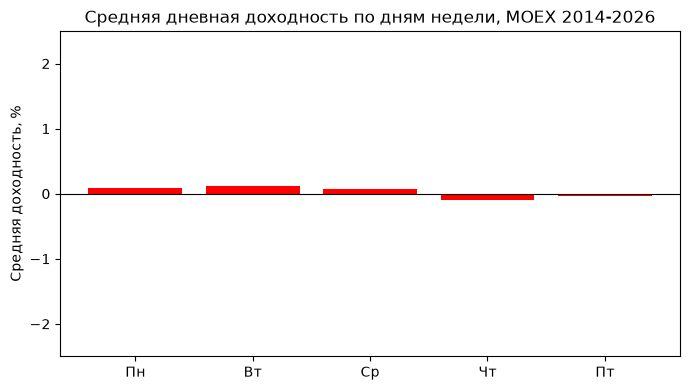

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(by_dow.index, by_dow["mean_pct"], color="red")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Средняя доходность, %")
ax.set_title("Средняя дневная доходность по дням недели, MOEX 2014-2026")

ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

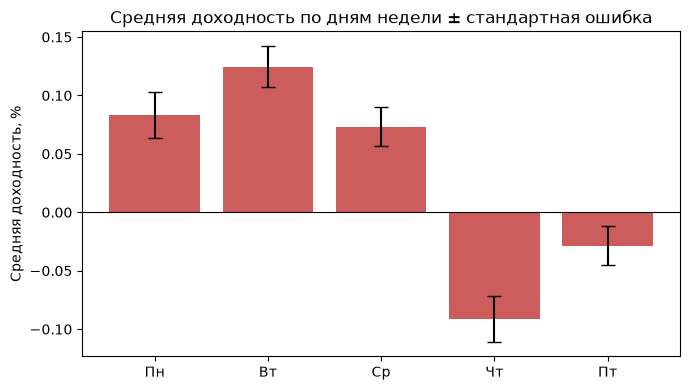

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(by_dow.index, by_dow["mean_pct"],
       yerr=by_dow["std"] / by_dow["count"]**0.5 * 100,
       capsize=5, color="indianred")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Средняя доходность, %")
ax.set_title("Средняя доходность по дням недели ± стандартная ошибка")

plt.tight_layout()
plt.show()

In [21]:
daily = prices.groupby("TRADEDATE")["RETURN"].mean().reset_index()
daily["DOW"] = daily["TRADEDATE"].dt.dayofweek

by_dow_daily = daily.groupby("DOW")["RETURN"].agg(["count", "mean", "std"])
by_dow_daily.index = DOW_NAMES

by_dow_daily["mean_pct"] = by_dow_daily["mean"] * 100
by_dow_daily["se_pct"] = by_dow_daily["std"] / by_dow_daily["count"]**0.5 * 100

by_dow_daily

,count,mean,std,mean_pct,se_pct
Пн,620,0.000781,0.015481,0.078145,0.062174
Вт,634,0.001318,0.012241,0.131791,0.048614
Ср,635,0.000808,0.011469,0.080787,0.045512
Чт,637,-0.000851,0.016054,-0.085070,0.063606
Пт,633,-0.000293,0.012016,-0.029263,0.047758


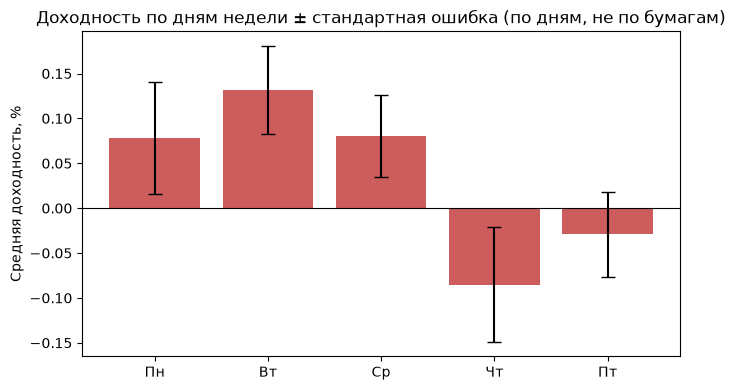

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(by_dow_daily.index, by_dow_daily["mean_pct"],
       yerr=by_dow_daily["se_pct"],
       capsize=5, color="indianred")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Средняя доходность, %")
ax.set_title("Доходность по дням недели ± стандартная ошибка (по дням, не по бумагам)")

plt.tight_layout()
plt.show()

### Наблюдения зависимы внутри дня

При счёте «бумага-день» получается 68 774 наблюдения, но 25 бумаг
в один день движутся вместе (24.02.2022 упали все) — это одно
событие, а не 25 независимых. Формула se = std/√n завышает точность.

Пересчёт по схеме «одна дата — одно наблюдение» (среднее по бумагам
внутри дня, 3 159 наблюдений): средние почти не изменились,
стандартные ошибки выросли втрое (0,017-0,020 → 0,046-0,064).

Следствие для выводов: различия внутри тройки Пн/Вт/Ср и отличие
пятницы от нуля перестали быть различимыми. Устойчивым остаётся
только разрыв между вторником и четвергом.

In [23]:
from scipy import stats

vt = daily.loc[daily["DOW"] == 1, "RETURN"]
cht = daily.loc[daily["DOW"] == 3, "RETURN"]

t_stat, p_value = stats.ttest_ind(vt, cht, equal_var=False)

print(f"вторник:  {vt.mean()*100:+.4f}%  (n={len(vt)})")
print(f"четверг:  {cht.mean()*100:+.4f}%  (n={len(cht)})")
print(f"разница:  {(vt.mean() - cht.mean())*100:+.4f}%")
print(f"t = {t_stat:.3f}, p = {p_value:.5f}")

вторник:  +0.1318%  (n=634)
четверг:  -0.0851%  (n=637)
разница:  +0.2169%
t = 2.709, p = 0.00685


In [24]:
import numpy as np

rng = np.random.default_rng(42)
counter = 0
N = 10_000

for _ in range(N):
    groups = rng.normal(0, 0.013, size=(5, 630))
    means = groups.mean(axis=1)
    hi, lo = means.argmax(), means.argmin()
    _, p = stats.ttest_ind(groups[hi], groups[lo], equal_var=False)
    if p < 0.05:
        counter += 1

print(f"значимых результатов: {counter}/{N} = {counter/N:.1%}")

значимых результатов: 2944/10000 = 29.4%


In [25]:
p_corrected = 0.00685 * 10
print(f"p после поправки Бонферрони: {p_corrected:.4f}")

p после поправки Бонферрони: 0.0685


In [26]:
observed_diff = 0.2169 / 100

rng = np.random.default_rng(2024)
extreme = 0
N = 20_000

pooled_std = daily["RETURN"].std()

for _ in range(N):
    groups = rng.normal(0, pooled_std, size=(5, 630))
    means = groups.mean(axis=1)
    if means.max() - means.min() >= observed_diff:
        extreme += 1

print(f"эмпирическое p = {extreme}/{N} = {extreme/N:.4f}")

эмпирическое p = 745/20000 = 0.0372


### Проверка гипотезы о различии дней недели

Наибольший разрыв: вторник (+0,132%) против четверга (-0,085%),
разница 0,217 п.п. за день.

Наивный t-тест Уэлча: t = 2,71, p = 0,0069.

Но пара выбрана ПОСЛЕ просмотра данных — взяты максимум и минимум
из пяти дней. Тест же считает p в предположении, что сравнение
назначено заранее.

Симуляция (10 000 прогонов, пять групп из одного распределения,
эффекта нет по построению): процедура «выбрать крайних и сравнить»
даёт p < 0,05 в 29,4% случаев вместо заявленных 5%.

Корректные оценки:
- Бонферрони (10 пар): p = 0,069 — не значимо
- Эмпирическая (20 000 прогонов, распределение размаха
  при отсутствии эффекта): p = 0,037

Вывод: различие значимо на уровне 5%, но с минимальным запасом.
Эмпирическая оценка предпочтительнее — она воспроизводит
фактическую процедуру отбора, а не идеализированную.